This analysis runs on the PLEnuM package:
https://github.com/PLEnuM-group/Plenum

In [1]:
%load_ext autoreload
%autoreload 2

# Preparations

In [2]:
# need to run once in the beginning to prepare all ingredients for the analysis
# this might take several minutes

# run these only if you haven't done so before
# load IceCube's effective area and rotate it to approximate other detectors
# %run ../../core/aeff_calculations.py

# # calculate the atmospheric neutrino background using MCEq (IceCube-centric)
# %run ../../core/atmospheric_background.py



# ## run these every time there are updates to resolution, binning, or mephistograms ##
# # load and prepare the energy and angular resolutions
# %run ../../core/resolution.py

# # gather all ingredients and save them as unified 'mephistogram' data structure
# %run ../../core/prepare_histograms.py

# Imports

In [3]:
import pickle
from os.path import join
from collections import namedtuple

import numpy as np
import pandas as pd
from aeff_calculations import calc_aeff_factor
from fluxes import (
    astro_flux,
    atmo_background,
)
import settings as st
from matplotlib.colors import LogNorm
from scipy.optimize import fmin_l_bfgs_b
from scipy.stats import chi2
from scipy.special import erfinv
from tools import get_mids
from mephisto import plot_mephistogram, plot_multiple_mephistograms, Mephistogram

from likelihood import poisson_llh

import seaborn as sns
plt = sns.mpl.pyplot


/home/hpc/capn/capn102h/miniconda3/envs/plenum/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Point-source binning!


# Generate IRF matrices

In [4]:
irf = pd.read_pickle(join(st.BASEPATH, "resources/detector_response_IC.pkl"))
print(irf.keys())
cos_zen_bins = irf["cos_zen_edges"]

dict_keys(['true_energy_edges', 'cos_zen_edges', 'angular_resolution_edges', 'reco_energy_bins', 'reco_energy_tensor', 'effective_area', 'angular_resolution_tensor'])


## effective area

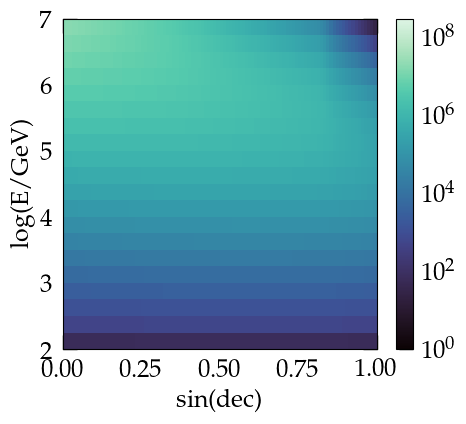

In [5]:
sindec_bins = -cos_zen_bins[::-1]
logE_bins = np.log10(irf["true_energy_edges"])
logE_reco_bins = np.log10(irf["reco_energy_bins"])

effective_area = Mephistogram(
    irf["effective_area"][::-1] * 1e4,  # m^2 -> cm^2
    (sindec_bins, logE_bins),
    ("sin(dec)", "log(E/GeV)"),
    make_hist=False,
)

effective_area.plot(norm=LogNorm(vmin=1, vmax=3E8))

In [6]:
effective_area

Mephistogram with 2 dimensions and shape (100, 20). Axis names are ('sin(dec)', 'log(E/GeV)').
[[6.35854697e+01 4.87186336e+02 1.10828523e+03 ... 9.22548516e+06
  1.28476365e+07 1.75958561e+07]
 [6.37213459e+01 4.88656925e+02 1.11272161e+03 ... 9.14261421e+06
  1.26562097e+07 1.71960786e+07]
 [6.38560008e+01 4.90114272e+02 1.11711814e+03 ... 9.01321936e+06
  1.23792401e+07 1.66443895e+07]
 ...
 [6.38440221e+01 4.89805201e+02 1.11554229e+03 ... 7.63830738e+03
  1.01824804e+03 7.13360297e+01]
 [6.31304841e+01 4.82046106e+02 1.09201309e+03 ... 5.78661606e+03
  7.17165687e+02 4.56272871e+01]
 [6.20169671e+01 4.69939644e+02 1.05531238e+03 ... 4.09689458e+03
  4.66637253e+02 2.66867731e+01]]

## energy resolution

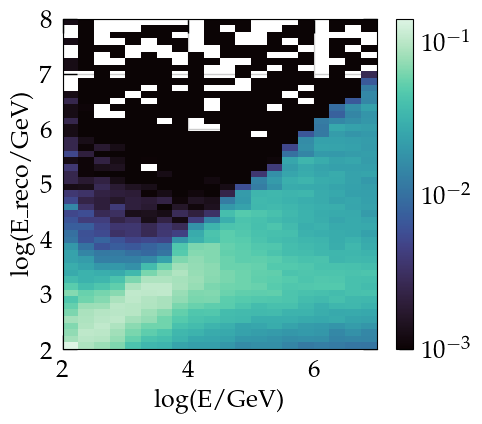

In [7]:
if True:
    energy_resolution = Mephistogram(
        irf["reco_energy_tensor"][:, 0, :],
        (logE_bins, logE_reco_bins),
        ("log(E/GeV)", "log(E_reco/GeV)"),
        make_hist=False,
    )
    energy_resolution.normalize(axis=1)
    energy_resolution.plot(norm=LogNorm(vmin=1E-3))
else:
    energy_resolution = None

## background flux

In [8]:
from scipy.interpolate import RegularGridInterpolator

In [9]:
with open(join(st.BASEPATH, "resources/MCEq_daemonflux.pckl"), "rb") as f:
    (e_grid, zen), bckg_flux = pickle.load(f)

# set up the interpolation function
rgi = RegularGridInterpolator(
    (e_grid, np.cos(np.deg2rad(zen))),
    np.log(bckg_flux),
    method=st.interpolation_method,
)

# finer interpolation for further steps
ss, em = np.meshgrid(get_mids(cos_zen_bins), get_mids(irf["true_energy_edges"]))
numu_bg = np.exp(rgi((em, ss))).T


In [10]:
# loop over detectors and rotate the local background flux to equatorial coordinates
# i.e. calculate the average bg flux per day in equatorial sin(dec)
bckg_flux = Mephistogram(
    numu_bg[::-1],
    (sindec_bins, logE_bins),
    ("sin(dec)", "log(E/GeV)"),
    make_hist=False,
)

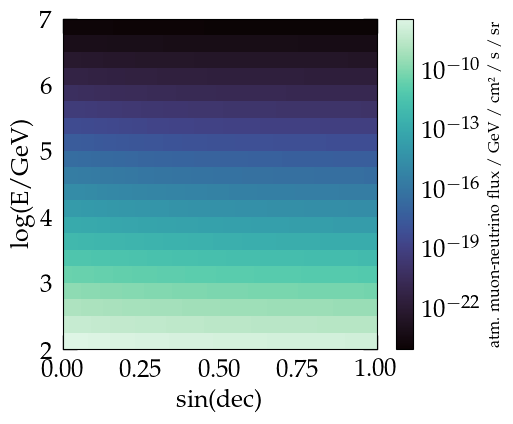

In [11]:
# visualization of bckg flux
plot_mephistogram(bckg_flux, norm=LogNorm())
cb = plt.gca().collections[0].colorbar
cb.set_label("atm. muon-neutrino flux / GeV / cm² / s / sr", fontsize="small")


# Source parameters

In [12]:
# livetime of 10yrs in seconds and days
print(st.LIVETIME, st.LIVETIME / 24 / 3600)
# Normalization energy of power law (E/E_NORM)^GAMMA_ASTRO
print(st.E_NORM)  # in GeV
# Source flux spectral index
# see https://arxiv.org/abs/2111.10299?context=astro-ph
print(st.GAMMA_ASTRO)  # spectral index
print(st.PHI_ASTRO)  # neutrinos * (E/E_NORM)^GAMMA_ASTRO / GeV / cm^2 / s / sr
print(st.BASEPATH)
print(st.LOCALPATH)


308975040.0 3576.1
100000.0
2.37
1.44e-18
/home/hpc/capn/capn102h/repos/Plenum
/home/hpc/capn/capn102h/repos/Plenum/local


# Source flux definition
$N_{\nu} = T_{\rm live} \cdot \int_{\Delta \Omega} d \Omega \, d E \, \int_{E_{\min}}^{E_{\max}} dE \, A_{\rm eff} \left( E, \sin(\delta)\right) \cdot \frac{d \Phi}{d E} $

Approximate the integral with a finite-binning approach:

aeff_factor =
$ 2\pi \cdot \Delta \sin (\delta) \, \Delta E \cdot A_{\rm eff} \left( E, \sin(\delta)\right) $ 

($2\pi = \int_0^{2\pi} d\phi$; $d \Omega = d \phi \cdot d \sin(\delta)$)

In [13]:
# we base the flux models on named-tuples
PL_flux = namedtuple("PL_flux", "norm gamma E0 shape")
diffuse_flux = PL_flux(st.PHI_ASTRO, st.GAMMA_ASTRO, st.E_NORM, "powerlaw")


# Config

In [14]:
# generic diffuse flux config
sindec_mids = get_mids(sindec_bins)
sindec_width = np.diff(sindec_bins)
ewidth = np.diff(irf["true_energy_edges"])

diffuse_config = dict(
    sindec_mids=sindec_mids,
    sindec_width=sindec_width,
    livetime=st.LIVETIME,
    ewidth=ewidth,
    diff_or_ps="diff",
)


### Full nominal (=Asimov) histograms in  sin(dec) - log(E)

Fit parameters for analysis:
* Global normalization of the atmospheric neutrino flux (background), $N_B$
* Global normalization of the astrophysical neutrino flux (signal), $N_S$
* Spectral index, GAMMA_ASTRO, of the astrophysical neutrino flux (signal), $\gamma$

In [15]:
aeff_factor = calc_aeff_factor(effective_area, **diffuse_config)

# asimov data
# in reconstructed energy
k_b = atmo_background(aeff_factor, bckg_flux, energy_resolution)
k_s = astro_flux(
    aeff_factor,
    10**aeff_factor.bin_mids[1],
    energy_resolution=energy_resolution,
    phi_scaling=1,
    flux_shape=diffuse_flux,
)
k_i = k_s + k_b

print("Asimov data sum:")
print("Background:", np.sum(k_b))
print("Signal:", np.sum(k_s))
print("S+B", np.sum(k_i))


Asimov data sum:
Background: 1682242.3747610836
Signal: 4319.252737967275
S+B 1686561.627499051


## Plotting of the event distributions

Text(0.5, 1.0, 'Signal astrophysical flux')

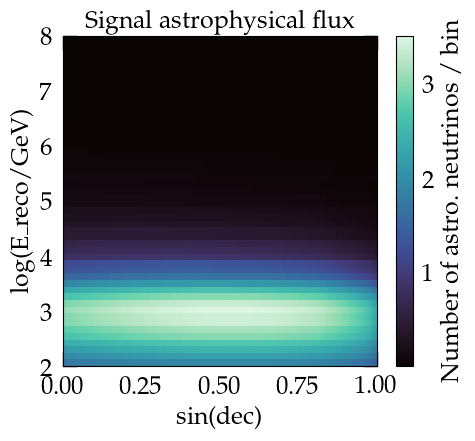

In [16]:
## signal
k_s.plot()
cb = plt.gca().collections[0].colorbar
cb.set_label("Number of astro. neutrinos / bin")
plt.title("Signal astrophysical flux")


Text(0.5, 1.0, 'Background atmospheric flux')

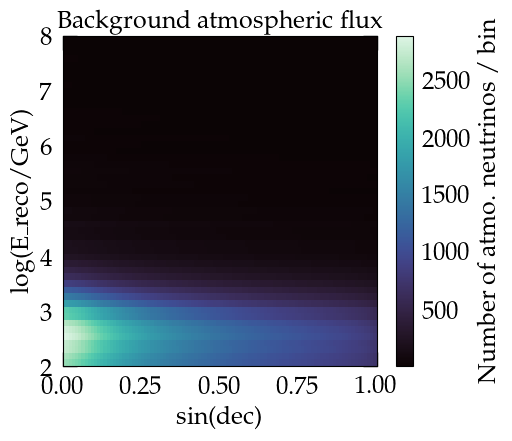

In [17]:
## atmo. background
k_b.plot()
cb = plt.gca().collections[0].colorbar
cb.set_label("Number of atmo. neutrinos / bin")
plt.title("Background atmospheric flux")


Text(0.5, 1.0, 'Combined S+B neutrino flux')

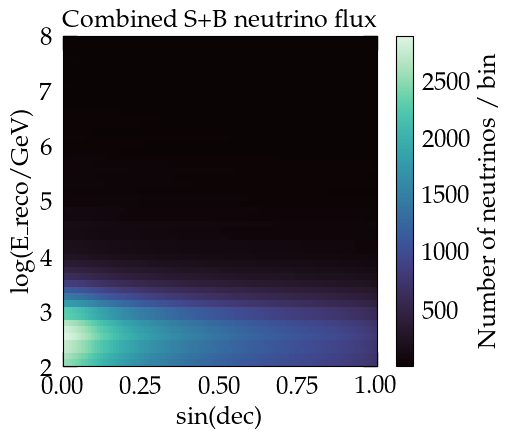

In [18]:
## atmo. background + astro. signal
k_i.plot()
cb = plt.gca().collections[0].colorbar
cb.set_label("Number of neutrinos / bin")
plt.title("Combined S+B neutrino flux")


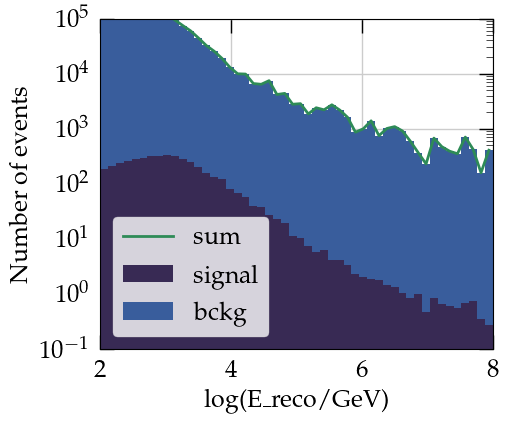

In [19]:
# summed 1D hist in log(E_reco)
f, axes = plt.subplots(figsize=(5, 4))
plot_multiple_mephistograms(
    (k_s.sum(axis=0, return_mephisto=True), k_b.sum(axis=0, return_mephisto=True)),
    labels=["signal", "bckg"],
    f=f,
    axes=axes,
)
k_i_en = k_i.sum(axis=0, return_mephisto=True)
plt.plot(k_i_en.bin_mids, k_i_en.histo, label="sum", color="seagreen")

plt.yscale("log")
plt.ylim(1e-1, 1e5)
plt.ylabel("Number of events")
plt.legend()


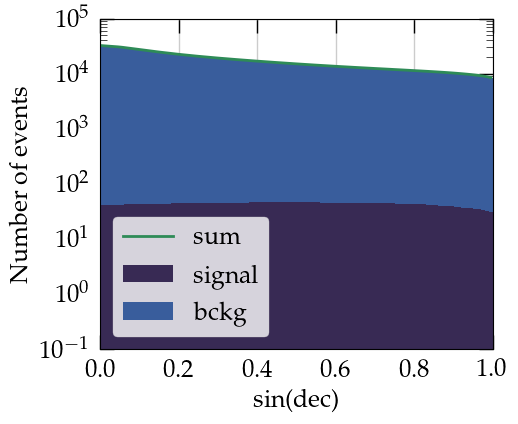

In [20]:
# summed 1D hist in sin(dec)
f, axes = plt.subplots(figsize=(5, 4))
plot_multiple_mephistograms(
    (k_s.sum(axis=1, return_mephisto=True), k_b.sum(axis=1, return_mephisto=True)),
    labels=["signal", "bckg"],
    f=f,
    axes=axes,
)
k_i_en = k_i.sum(axis=1, return_mephisto=True)
plt.plot(k_i_en.bin_mids, k_i_en.histo, label="sum", color="seagreen")

plt.yscale("log")
plt.ylim(1e-1, 1e5)
plt.ylabel("Number of events")
plt.legend()


### DEMO: Significance test Background vs. Background + Signal

$ \mathcal{L}({\rm data}~k~ |~{\rm hypothesis}~\mu)
    = \prod_{{\rm bin\,}ij}^{N_{\rm bins}} \frac{\mu_{ij}^{k_{ij}}}{k_{ij}!}\cdot
    \exp \left( -\mu_{ij} \right)$


Background hypothesis $H_0(\mu = N_B)$ : only atmospheric neutrino flux

Signal hypothesis $H_1(\mu = \{N_B, N_S, \gamma \})$: atmospheric neutrino flux + astrophysical neutrino flux

Idea: data ($k$) are the perfect representation of our expectation; the hypothesis ($\mu$) is the model with the free parameters we'd like to know
For numerical stability, we directly evaluate (see https://en.wikipedia.org/wiki/Stirling%27s_approximation for approximation of the faculty function)
$-2 \log (\mathcal{L}) = -2\cdot (k_i \cdot \log(\mu_i)
            - \mu_i
            - 0.5 \cdot \log(2 \pi \cdot k_i)
            + k_i
            - k_i \cdot \log(k_i))$

In [21]:
def diffuse_llh(
    x,
    aeff_factor,
    bckg_flux,
    energy_resolution,
    k_i,
):
    """
    Define the Log-Likelihood function depending
    on the model parameters (=fit parameters)

    Fit parameters:
    ---------------
    (= x) for the standard power law:
    x[0]: background normalization scaling
    x[1]: signal normalization scaling
    x[2]: signal spectral index

    Other parameters:
    -----------------
    mu_b_base: effective area factor for background
    mu_s_base: effective area factor for signal
    k_i: observation/asimov data
    e_norm: normalization energy
    """

    mu_b = atmo_background(
        aeff_factor=aeff_factor,
        bckg_vals=bckg_flux * x[0],
        energy_resolution=energy_resolution,
    )
    mu_s = astro_flux(
        aeff_factor=aeff_factor,
        emids=10 ** aeff_factor.bin_mids[1],
        energy_resolution=energy_resolution,
        phi_scaling=x[1],
        flux_shape=PL_flux(
            st.PHI_ASTRO, *x[2:], st.E_NORM, "powerlaw"
        ),  # here we generate a flux tuple with the current parameters
    )
    return poisson_llh(mu_b + mu_s, k_i)

The significance of the hypothesis test is evaluated using the test statistic

$TS = -2 \log ( H_0(\mu = {\rm best fit}) / H_1(\mu = {\rm best fit}) )$

where the best-fit parameters are obtained with an optimization function `fmin_l_bfgs_b`.


The data (k) is modeled as 'Asimov data', the TS calculation fulfills the requirements of Wilks' theorem, and thus we know that the underlying TS distribution
follows a $\chi ^2$ distribution, here with 2 degrees of freedom.

The p-value of the Asimov data set represents the expected significance of an analysis with real data if it has the same model parameters. It's the integral of the $\chi ^2$ distribution from TS to infinity (`chi.sf(TS)`). The p-value in terms of Gaussian standard deviations can be calculated via the inverse error function (`erfinv`).

In [22]:
aeff_factor = calc_aeff_factor(effective_area, **diffuse_config)

# asimov data
# in reconstructed energy
k_b = atmo_background(aeff_factor, bckg_flux, energy_resolution)
k_s = astro_flux(
    aeff_factor,
    10 ** aeff_factor.bin_mids[1],
    energy_resolution=energy_resolution,
    phi_scaling=1,
    flux_shape=diffuse_flux,
)
k_i = k_s + k_b

print("Asimov data sum:")
print("Background:", np.sum(k_b))
print("Signal:", np.sum(k_s))
print("S+B", np.sum(k_i))

_kw = dict(
    aeff_factor=aeff_factor,
    bckg_flux=bckg_flux,
    energy_resolution=energy_resolution,
    k_i=k_i,
)
# define the fitting functions with all parameters
# background only, 1 free parameter
local_llh = lambda x: diffuse_llh((x[0], 0, 2), **_kw)
# background + signal, 3 free parameters
global_llh = lambda x: diffuse_llh(x, **_kw)
# ... and fit both hypotheses!
# background first
out_bckg = fmin_l_bfgs_b(
    local_llh,
    x0=(1.2,),
    approx_grad=True,
)
print("Bckg-only normalization:", out_bckg[0])
# .. then signal+background
out_comp = fmin_l_bfgs_b(
    global_llh,
    x0=(1.2, 3.0, 1.2),
    approx_grad=True,
)
print("Signal fit parameters:", out_comp[0])

## Note: out_bckg/comp[1] contains the value of the
# LLH function with the optimized model parameters
# out_bckg[1] - out_comp[1] == -2log(L(H_0) / L(H_1)) = TS (see above)

# calculate p-value and significance with Wilks' theorem and 2 d.o.f
pval = chi2.sf(out_bckg[1] - out_comp[1], 2)
significance = erfinv(1 - pval) * np.sqrt(2)
print("P-VALUE:", pval, "SIGNIFICANCE:", significance)
# ... we do quite well without accounting for systematic uncertainties :D

Asimov data sum:
Background: 1682242.3747610836
Signal: 4319.252737967275
S+B 1686561.627499051
Bckg-only normalization: [1.00256756]
Signal fit parameters: [1.00000118 1.00022525 2.36976835]
P-VALUE: 0.1311500695718625 SIGNIFICANCE: 1.5095821864951888
